# CCP4 Electron Density Map Visualization — 14GS

Visualises `14gs.ccp4` (CCP4/MRC format, from PDBe EDS).  
Pocket atom coordinates are overlaid from the CrossDocked2020 pocket PDB.

| Plot | What it shows |
|---|---|
| Map metadata | Cell, grid, statistics |
| Density histogram | Value distribution, σ contour levels |
| 2D orthogonal slices | Three planes through pocket centroid with atom overlay |
| 3D isosurface | Interactive Plotly: density + pocket atoms |

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go
import gemmi
import math
from pathlib import Path

CCP4_FILE  = Path("14gs.ccp4")
POCKET_PDB = Path("../voxbind/dataset/data/crossdocked_pocket10/"
                  "GSTP1_HUMAN_2_210_0/14gs_A_rec_20gs_cbd_lig_tt_min_0_pocket10.pdb")

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## 1. Load Map and Metadata

In [3]:
m = gemmi.read_ccp4_map(str(CCP4_FILE))
m.setup(float('nan'))
grid = m.grid

arr  = np.array(grid, dtype=np.float32)   # (nu, nv, nw)
cell = grid.unit_cell
nu, nv, nw = arr.shape

mean  = float(np.nanmean(arr))
sigma = float(np.nanstd(arr))
pct_neg = 100.0 * np.sum(arr < 0) / arr.size

print(f"Grid shape  : {nu} x {nv} x {nw}")
print(f"Space group : {grid.spacegroup.hm}")
print(f"Unit cell   : a={cell.a:.3f}  b={cell.b:.3f}  c={cell.c:.3f} \u00c5")
print(f"              \u03b1={cell.alpha:.2f}  \u03b2={cell.beta:.2f}  \u03b3={cell.gamma:.2f}\u00b0")
print(f"Map mean    : {mean:.4f}")
print(f"Map sigma   : {sigma:.4f}")
print(f"% negative  : {pct_neg:.1f}%  (>50% \u2192 EDS/difference map)")

Grid shape  : 60 x 72 x 50
Space group : C 1 2 1
Unit cell   : a=78.651  b=91.826  c=69.143 Å
              α=90.00  β=98.25  γ=90.00°
Map mean    : 0.0000
Map sigma   : 0.1973
% negative  : 52.8%  (>50% → EDS/difference map)


## 2. Load Pocket Atoms

In [4]:
st = gemmi.read_structure(str(POCKET_PDB))

pocket_atoms = []  # list of (x, y, z, element)
for model in st:
    for chain in model:
        for res in chain:
            for atom in res:
                pos = atom.pos
                pocket_atoms.append((pos.x, pos.y, pos.z, atom.element.name))

pocket_xyz   = np.array([[a[0], a[1], a[2]] for a in pocket_atoms])  # (N, 3) Angstrom
pocket_elems = [a[3] for a in pocket_atoms]

# Cartesian \u2192 fractional \u2192 grid index
pocket_grid = np.zeros_like(pocket_xyz)
for i, (x, y, z) in enumerate(pocket_xyz):
    frac = cell.fractionalize(gemmi.Position(x, y, z))
    pocket_grid[i] = [frac.x * nu, frac.y * nv, frac.z * nw]

centroid = pocket_grid.mean(axis=0)
ELEM_COLOR = {"C": "gray", "N": "blue", "O": "red", "S": "goldenrod"}

print(f"Pocket atoms    : {len(pocket_atoms)}")
print(f"Centroid (grid) : u={centroid[0]:.1f}  v={centroid[1]:.1f}  w={centroid[2]:.1f}")

Pocket atoms    : 255
Centroid (grid) : u=19.7  v=7.6  w=19.6


## 3. Density Histogram

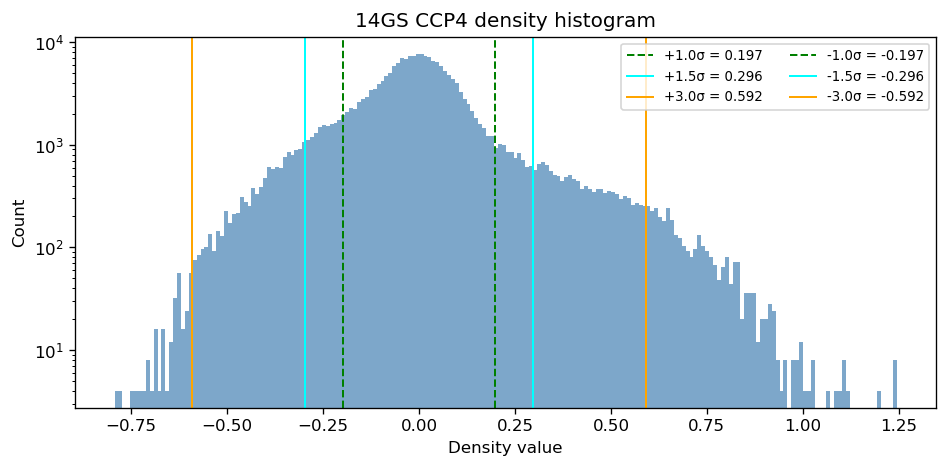

Contour levels:  +1.5σ = 0.2959   +3σ = 0.5919
               −1.5σ = -0.2959   −3σ = -0.5919


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
vals = arr.ravel()
ax.hist(vals, bins=200, color="steelblue", alpha=0.7, edgecolor="none")

for level, color, ls in [
    ( 1.0, "green",  "--"),
    ( 1.5, "cyan",   "-"),
    ( 3.0, "orange", "-"),
    (-1.0, "green",  "--"),
    (-1.5, "cyan",   "-"),
    (-3.0, "orange", "-"),
]:
    v = mean + level * sigma
    ax.axvline(v, color=color, ls=ls, lw=1.2, label=f"{level:+.1f}\u03c3 = {v:.3f}")

ax.set_xlabel("Density value")
ax.set_ylabel("Count")
ax.set_title("14GS CCP4 density histogram")
ax.legend(fontsize=8, ncol=2)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

print(f"Contour levels:  +1.5\u03c3 = {mean + 1.5*sigma:.4f}   +3\u03c3 = {mean + 3*sigma:.4f}")
print(f"               \u22121.5\u03c3 = {mean - 1.5*sigma:.4f}   \u22123\u03c3 = {mean - 3*sigma:.4f}")

## 4. 2D Orthogonal Slices Through Pocket Centroid

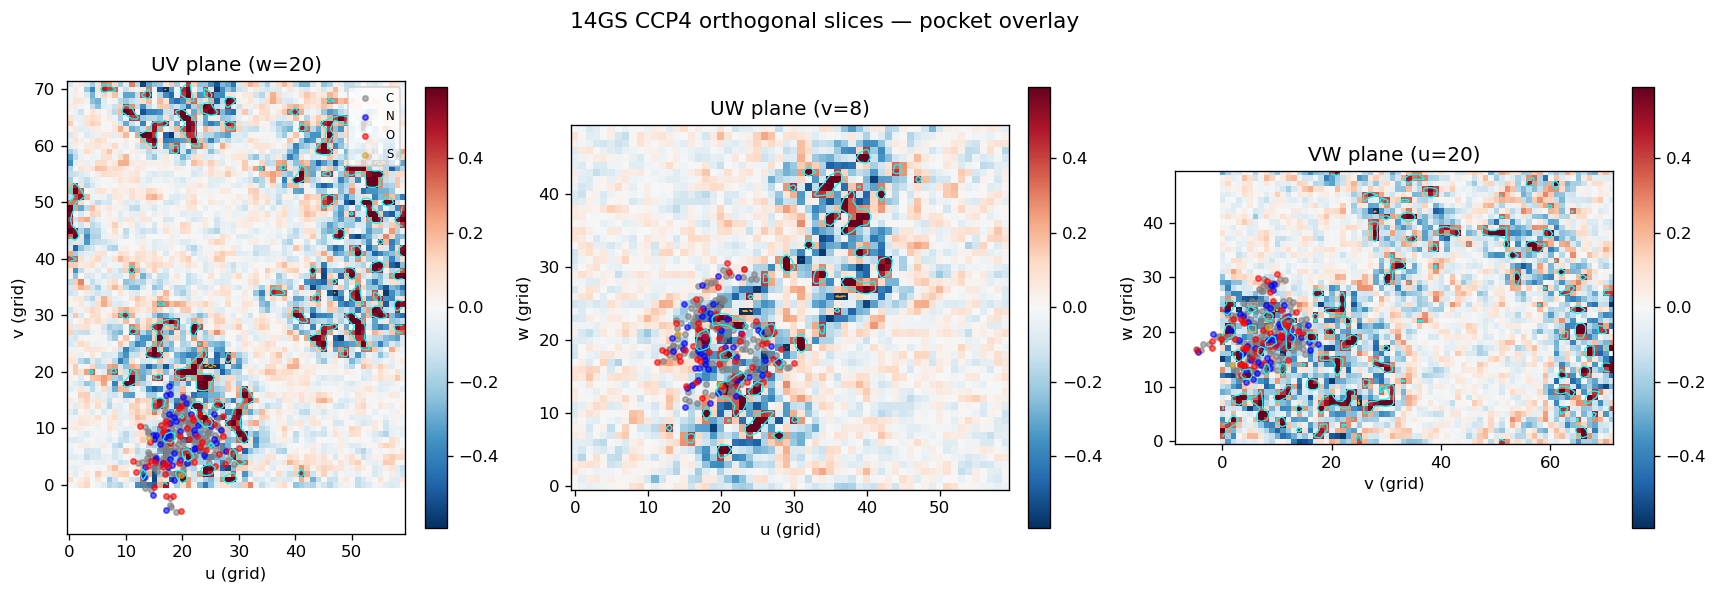

In [6]:
ci = int(np.clip(round(centroid[0]), 0, nu - 1))
cj = int(np.clip(round(centroid[1]), 0, nv - 1))
ck = int(np.clip(round(centroid[2]), 0, nw - 1))

vmin, vmax = mean - 3 * sigma, mean + 3 * sigma

slice_specs = [
    (f"UV plane (w={ck})", arr[:, :, ck], pocket_grid[:, 0], pocket_grid[:, 1], "u (grid)", "v (grid)"),
    (f"UW plane (v={cj})", arr[:, cj, :], pocket_grid[:, 0], pocket_grid[:, 2], "u (grid)", "w (grid)"),
    (f"VW plane (u={ci})", arr[ci, :, :], pocket_grid[:, 1], pocket_grid[:, 2], "v (grid)", "w (grid)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, slc, px, py, xl, yl) in zip(axes, slice_specs):
    im = ax.imshow(slc.T, origin="lower", cmap="RdBu_r",
                   vmin=vmin, vmax=vmax, aspect="equal")
    ax.contour(slc.T, levels=[mean + 1.5 * sigma],
               colors=["cyan"],   linewidths=0.8)
    ax.contour(slc.T, levels=[mean - 3.0 * sigma],
               colors=["orange"], linewidths=0.8, linestyles="dashed")

    for elem in sorted(set(pocket_elems)):
        mask = np.array([e == elem for e in pocket_elems])
        ax.scatter(np.array(px)[mask], np.array(py)[mask],
                   c=ELEM_COLOR.get(elem, "purple"), s=10,
                   alpha=0.6, label=elem)

    ax.set_title(title)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes[0].legend(fontsize=7, loc="upper right")
plt.suptitle("14GS CCP4 orthogonal slices \u2014 pocket overlay", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Pocket Atoms (Plotly)

A sub-box around the pocket centroid is extracted and rendered as two isosurfaces:  
**blue** = +1.5σ (positive density),  **red** = −3σ (negative density, e.g. missing atoms).

In [7]:
# Sub-box around pocket centroid
R = 18
i0, i1 = max(0, ci - R), min(nu, ci + R)
j0, j1 = max(0, cj - R), min(nv, cj + R)
k0, k1 = max(0, ck - R), min(nw, ck + R)
sub = arr[i0:i1, j0:j1, k0:k1]

# Grid indices → Cartesian Å (monoclinic: x = a*fa + c*cos(β)*fc)
beta_rad = math.radians(cell.beta)
a_len, b_len, c_len = cell.a, cell.b, cell.c

ii = np.arange(i0, i1, dtype=float) / nu
jj = np.arange(j0, j1, dtype=float) / nv
kk = np.arange(k0, k1, dtype=float) / nw
Fi, Fj, Fk = np.meshgrid(ii, jj, kk, indexing="ij")

Xc = a_len * Fi + c_len * math.cos(beta_rad) * Fk
Yc = b_len * Fj
Zc = c_len * math.sin(beta_rad) * Fk

pos_thresh = mean + 1.5 * sigma
neg_thresh = mean - 3.0 * sigma

traces = []

traces.append(go.Isosurface(
    x=Xc.ravel(), y=Yc.ravel(), z=Zc.ravel(),
    value=sub.ravel(),
    isomin=pos_thresh, isomax=pos_thresh,
    surface_count=1,
    colorscale=[[0, "blue"], [1, "blue"]],
    showscale=False, opacity=0.35,
    name="+1.5σ",
    caps=dict(x_show=False, y_show=False, z_show=False),
))

traces.append(go.Isosurface(
    x=Xc.ravel(), y=Yc.ravel(), z=Zc.ravel(),
    value=sub.ravel(),
    isomin=neg_thresh, isomax=neg_thresh,
    surface_count=1,
    colorscale=[[0, "red"], [1, "red"]],
    showscale=False, opacity=0.25,
    name="−3σ",
    caps=dict(x_show=False, y_show=False, z_show=False),
))

for elem in sorted(set(pocket_elems)):
    mask = np.array([e == elem for e in pocket_elems])
    xyz  = pocket_xyz[mask]
    traces.append(go.Scatter3d(
        x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
        mode="markers",
        marker=dict(size=3, color=ELEM_COLOR.get(elem, "purple"), opacity=0.8),
        name=f"pocket {elem}",
    ))

fig = go.Figure(traces)
fig.update_layout(
    title="14GS CCP4 — 3D isosurface + pocket atoms",
    scene=dict(
        xaxis_title="X (Å)",
        yaxis_title="Y (Å)",
        zaxis_title="Z (Å)",
        aspectmode="data",
    ),
    width=800, height=650,
)
fig.show()

## 6. Image Resolution

The map grid directly determines the **sampling resolution** (Nyquist limit).  
The **crystallographic resolution** (from deposited structure factors) sets the true information limit.

In [9]:
# ── Voxel size along each crystallographic axis ───────────────────────────
vox_a = cell.a / nu   # Å / voxel along a
vox_b = cell.b / nv   # Å / voxel along b
vox_c = cell.c / nw   # Å / voxel along c

# Nyquist limit: finest detail the grid can represent = 2 × voxel size
nyq_a = 2 * vox_a
nyq_b = 2 * vox_b
nyq_c = 2 * vox_c

# Average voxel size (isotropic approximation)
vox_mean = (vox_a + vox_b + vox_c) / 3

print("=== CCP4 Map Resolution ===")
print(f"Grid           : {nu} × {nv} × {nw}")
print(f"Unit cell      : a={cell.a:.3f}  b={cell.b:.3f}  c={cell.c:.3f}  (Å)")
print()
print(f"Voxel size     : {vox_a:.3f} × {vox_b:.3f} × {vox_c:.3f}  Å/voxel  (a × b × c)")
print(f"               = {vox_mean:.3f} Å  (mean)")
print()
print(f"Nyquist limit  : {nyq_a:.3f} × {nyq_b:.3f} × {nyq_c:.3f}  Å  (2 × voxel)")
print(f"               = {2*vox_mean:.3f} Å  (mean) — finest resolvable feature")
print()
print(f"Crystallographic resolution (from SF file): 2.80 Å")
print(f"  → Nyquist ({2*vox_mean:.2f} Å) < d_min (2.80 Å): grid is adequately sampled")

=== CCP4 Map Resolution ===
Grid           : 60 × 72 × 50
Unit cell      : a=78.651  b=91.826  c=69.143  (Å)

Voxel size     : 1.311 × 1.275 × 1.383  Å/voxel  (a × b × c)
               = 1.323 Å  (mean)

Nyquist limit  : 2.622 × 2.551 × 2.766  Å  (2 × voxel)
               = 2.646 Å  (mean) — finest resolvable feature

Crystallographic resolution (from SF file): 2.80 Å
  → Nyquist (2.65 Å) < d_min (2.80 Å): grid is adequately sampled


## 7. Full-Map Density Scatter (Plotly)

Every voxel with |density| ≥ 1σ is plotted as a point in Cartesian Å space,\n
coloured by its raw density value (RdBu: blue = positive, red = negative).

In [10]:
beta_rad = math.radians(cell.beta)
a_len, b_len, c_len = cell.a, cell.b, cell.c

# ── Full Cartesian grid for all 60×72×50 voxels ───────────────────────────
ii = np.arange(nu, dtype=np.float32) / nu
jj = np.arange(nv, dtype=np.float32) / nv
kk = np.arange(nw, dtype=np.float32) / nw
Fi, Fj, Fk = np.meshgrid(ii, jj, kk, indexing="ij")

Xc_all = (a_len * Fi + c_len * math.cos(beta_rad) * Fk).ravel()
Yc_all = (b_len * Fj).ravel()
Zc_all = (c_len * math.sin(beta_rad) * Fk).ravel()
vals   = arr.ravel()

# ── Keep only voxels with |density| >= 1σ ────────────────────────────────
threshold = 1.0 * sigma
mask = np.abs(vals) >= threshold

Xc = Xc_all[mask]
Yc = Yc_all[mask]
Zc = Zc_all[mask]
v  = vals[mask]

print(f"Total voxels          : {vals.size:,}  ({nu}\u00d7{nv}\u00d7{nw})")
print(f"Plotted (|\u03c1| \u2265 1\u03c3)     : {mask.sum():,}")
print(f"  positive (\u2265+1\u03c3)    : {(v > 0).sum():,}")
print(f"  negative (\u2264-1\u03c3)    : {(v < 0).sum():,}")

# ── Scatter3d coloured by density value ───────────────────────────────────
clim = 2.0 * sigma   # symmetric colour limits

fig = go.Figure(go.Scatter3d(
    x=Xc, y=Yc, z=Zc,
    mode="markers",
    marker=dict(
        size=2,
        color=v,
        colorscale="RdBu",
        reversescale=True,          # blue = positive, red = negative
        cmin=-clim,
        cmax= clim,
        opacity=0.6,
        colorbar=dict(
            title="\u03c1 (density)",
            thickness=14,
            len=0.65,
        ),
    ),
    hovertemplate="x=%{x:.1f} \u00c5<br>y=%{y:.1f} \u00c5<br>z=%{z:.1f} \u00c5<br>\u03c1=%{marker.color:.4f}<extra></extra>",
))

fig.update_layout(
    title=f"14GS CCP4 — density scatter (|\u03c1| \u2265 1\u03c3, {mask.sum():,} points)",
    scene=dict(
        xaxis_title="X (\u00c5)",
        yaxis_title="Y (\u00c5)",
        zaxis_title="Z (\u00c5)",
        aspectmode="data",
        bgcolor="rgb(15,15,15)",
    ),
    paper_bgcolor="rgb(25,25,25)",
    font_color="white",
    width=900, height=700,
)
fig.show()

Total voxels          : 216,000  (60×72×50)
Plotted (|ρ| ≥ 1σ)     : 49,422
  positive (≥+1σ)    : 23,254
  negative (≤-1σ)    : 26,168


## 8. Density Scatter + Pocket Atoms — Aligned to VoxBind Grid

The CCP4 map is sampled on the **64³ × 0.25 Å VoxBind grid** centred on the ligand centroid.

| Layer | What is shown |
|---|---|
| Density scatter | |ρ| ≥ 1σ voxels — **blue** = positive, **red** = negative |
| Pocket atoms | C / N / O / S coloured spheres (atoms within ±8 Å box) |
| Ligand atoms | lime diamonds (CBD ligand from CrossDocked SDF) |
| Wireframe | dashed box marks the ±8 Å grid boundary |

In [20]:
import math
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import RegularGridInterpolator
from rdkit import Chem
from pathlib import Path

# ── VoxBind grid parameters ────────────────────────────────────────────────
VOXEL_RES = 0.25        # Å / voxel  (vox/default.yaml)
GRID_SIZE  = 64         # voxels per dimension
HALF       = VOXEL_RES * GRID_SIZE / 2   # 8 Å

# ── 1. Ligand centroid (CrossDocked SDF) ───────────────────────────────────
LIGAND_SDF = Path("../voxbind/dataset/data/crossdocked_pocket10/"
                  "GSTP1_HUMAN_2_210_0/14gs_A_rec_20gs_cbd_lig_tt_min_0.sdf")
supplier   = Chem.SDMolSupplier(str(LIGAND_SDF), removeHs=True)
lig_mol    = next(mol for mol in supplier if mol is not None)
lig_xyz    = np.array(lig_mol.GetConformer().GetPositions(), dtype=np.float64)
ctr        = lig_xyz.mean(axis=0)
print(f"Ligand centroid : x={ctr[0]:.2f}  y={ctr[1]:.2f}  z={ctr[2]:.2f} Å")
print(f"Ligand atoms    : {len(lig_xyz)}")

# ── 2. Build 64³ Cartesian query grid centred on the ligand ───────────────
# voxel i → offset = (i − (G−1)/2) × res  (origin at voxel G/2)
grid_1d = (np.arange(GRID_SIZE, dtype=np.float32) - (GRID_SIZE - 1) / 2.0) * VOXEL_RES
gi, gj, gk = np.meshgrid(grid_1d, grid_1d, grid_1d, indexing="ij")
Gx = (ctr[0] + gi).ravel()
Gy = (ctr[1] + gj).ravel()
Gz = (ctr[2] + gk).ravel()

# ── 3. Cartesian → fractional → CCP4 grid indices (monoclinic) ───────────
beta_rad        = math.radians(cell.beta)
a_len, b_len, c_len = cell.a, cell.b, cell.c

frac_b = Gy / b_len
frac_c = Gz / (c_len * math.sin(beta_rad))
frac_a = (Gx - frac_c * c_len * math.cos(beta_rad)) / a_len

ci_q = (frac_a * nu) % nu
cj_q = (frac_b * nv) % nv
ck_q = (frac_c * nw) % nw

# ── 4. Trilinear interpolation with periodic boundary ─────────────────────
arr_w = np.pad(arr, 1, mode="wrap")   # (nu+2, nv+2, nw+2)
interp = RegularGridInterpolator(
    (np.arange(nu + 2, dtype=np.float32),
     np.arange(nv + 2, dtype=np.float32),
     np.arange(nw + 2, dtype=np.float32)),
    arr_w, method="linear", bounds_error=False, fill_value=None,
)
density_64 = interp(np.stack([ci_q + 1, cj_q + 1, ck_q + 1], axis=1))

d_mean  = float(density_64.mean())
d_sigma = float(density_64.std())
print(f"\n64³ density crop : mean={d_mean:.4f}  sigma={d_sigma:.4f}")

# ── 5. Filter density to |ρ| ≥ 1σ ─────────────────────────────────────────
threshold = 1.0 * d_sigma
dmask  = np.abs(density_64) >= threshold
Xd = gi.ravel()[dmask]
Yd = gj.ravel()[dmask]
Zd = gk.ravel()[dmask]
vals = density_64[dmask]
print(f"Density points |ρ| ≥ 1σ : {dmask.sum():,} / {density_64.size:,}  "
      f"({100*dmask.sum()/density_64.size:.1f}%)")

# ── 6. Pocket atoms relative to ligand centroid ────────────────────────────
pocket_rel = pocket_xyz - ctr        # (N, 3) centred at origin
in_grid    = np.all(np.abs(pocket_rel) <= HALF, axis=1)
poc_rel    = pocket_rel[in_grid]
elems_in   = [e for e, m in zip(pocket_elems, in_grid) if m]
print(f"Pocket atoms in grid    : {in_grid.sum()} / {len(pocket_xyz)}")

# ── 7. Build Plotly figure ─────────────────────────────────────────────────
ELEM_COL = {"C": "silver", "N": "cornflowerblue", "O": "tomato", "S": "gold"}
clim     = 2.0 * d_sigma
traces   = []

# Density scatter (colored by value)
traces.append(go.Scatter3d(
    x=Xd, y=Yd, z=Zd,
    mode="markers",
    marker=dict(
        size=2,
        color=vals,
        colorscale="RdBu",
        reversescale=True,          # blue = positive, red = negative
        cmin=-clim, cmax=clim,
        opacity=0.55,
        colorbar=dict(
            title="ρ (density)",
            thickness=14, len=0.65,
            tickfont=dict(color="white"),
            # titlefont=dict(color="white"),
        ),
    ),
    name="density |ρ|≥1σ",
    hovertemplate="Δx=%{x:.2f} Å<br>Δy=%{y:.2f} Å<br>Δz=%{z:.2f} Å<br>ρ=%{marker.color:.4f}<extra></extra>",
))

# Pocket atoms (one trace per element)
for elem in sorted(set(elems_in)):
    mask_e = np.array([e == elem for e in elems_in])
    xyz_e  = poc_rel[mask_e]
    traces.append(go.Scatter3d(
        x=xyz_e[:, 0], y=xyz_e[:, 1], z=xyz_e[:, 2],
        mode="markers",
        marker=dict(size=5, color=ELEM_COL.get(elem, "purple"), opacity=0.9),
        name=f"pocket {elem}",
    ))

# Ligand atoms
lig_rel = lig_xyz - ctr
traces.append(go.Scatter3d(
    x=lig_rel[:, 0], y=lig_rel[:, 1], z=lig_rel[:, 2],
    mode="markers",
    marker=dict(size=7, color="lime", symbol="diamond", opacity=0.95),
    name="ligand (CBD)",
))

# Wireframe box = VoxBind grid boundary
B = HALF
corners = np.array([
    [-B,-B,-B],[-B,-B,B],[-B,B,-B],[-B,B,B],
    [ B,-B,-B],[ B,-B,B],[ B,B,-B],[ B,B,B],
])
edges = [(0,1),(0,2),(1,3),(2,3),(4,5),(4,6),(5,7),(6,7),(0,4),(1,5),(2,6),(3,7)]
xs, ys, zs = [], [], []
for i, j in edges:
    xs += [corners[i,0], corners[j,0], None]
    ys += [corners[i,1], corners[j,1], None]
    zs += [corners[i,2], corners[j,2], None]
traces.append(go.Scatter3d(
    x=xs, y=ys, z=zs, mode="lines",
    line=dict(color="white", width=1.5, dash="dash"),
    name=f"VoxBind grid (±{B:.0f} Å)",
))

fig = go.Figure(traces)
fig.update_layout(
    title=(f"14GS — density scatter + pocket atoms in VoxBind {GRID_SIZE}³ grid  "
           f"(±{B:.0f} Å, {dmask.sum():,} density points)"),
    legend=dict(x=0.01, y=0.99, font_color="white"),
    scene=dict(
        xaxis_title="ΔX (Å)",
        yaxis_title="ΔY (Å)",
        zaxis_title="ΔZ (Å)",
        aspectmode="cube",
        bgcolor="rgb(15,15,15)",
        xaxis=dict(showbackground=False, gridcolor="rgba(255,255,255,0.1)",
                   range=[-B-1, B+1]),
        yaxis=dict(showbackground=False, gridcolor="rgba(255,255,255,0.1)",
                   range=[-B-1, B+1]),
        zaxis=dict(showbackground=False, gridcolor="rgba(255,255,255,0.1)",
                   range=[-B-1, B+1]),
    ),
    paper_bgcolor="rgb(25,25,25)",
    font_color="white",
    width=900, height=750,
)
fig.show()

Ligand centroid : x=24.26  y=6.69  z=27.79 Å
Ligand atoms    : 22

64³ density crop : mean=-0.0092  sigma=0.2299
Density points |ρ| ≥ 1σ : 83,751 / 262,144  (31.9%)
Pocket atoms in grid    : 100 / 255
